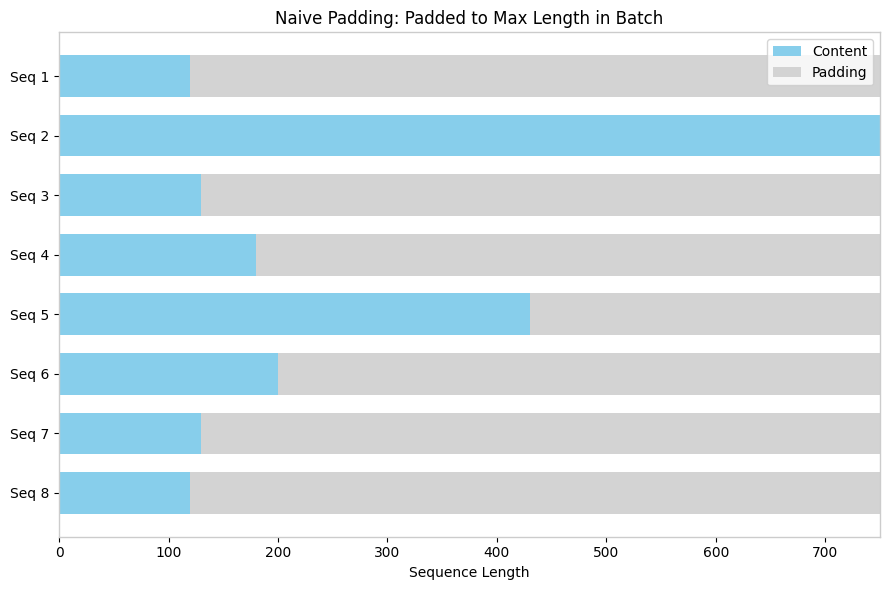

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Sequence content lengths (eyeballed from your plot)
content_lengths = [120, 750, 130, 180, 430, 200, 130, 120]
max_len = max(content_lengths)
labels = [f"Seq {i+1}" for i in range(len(content_lengths))]

fig, ax = plt.subplots(figsize=(9, 6))

y = np.arange(len(content_lengths))

# Plot padding first (full bars), then content on top
ax.barh(y, content_lengths, color="#87ceeb", label="Content", height=0.7)
ax.barh(y, [max_len - c for c in content_lengths], left=content_lengths, color="#d3d3d3", label="Padding", height=0.7)

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Sequence Length")
ax.set_title("Naive Padding: Padded to Max Length in Batch")
ax.legend(loc="upper right")
ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#cccccc")
    spine.set_linewidth(1)

plt.tight_layout()
plt.savefig("naive_padding.png", dpi=300, bbox_inches="tight")

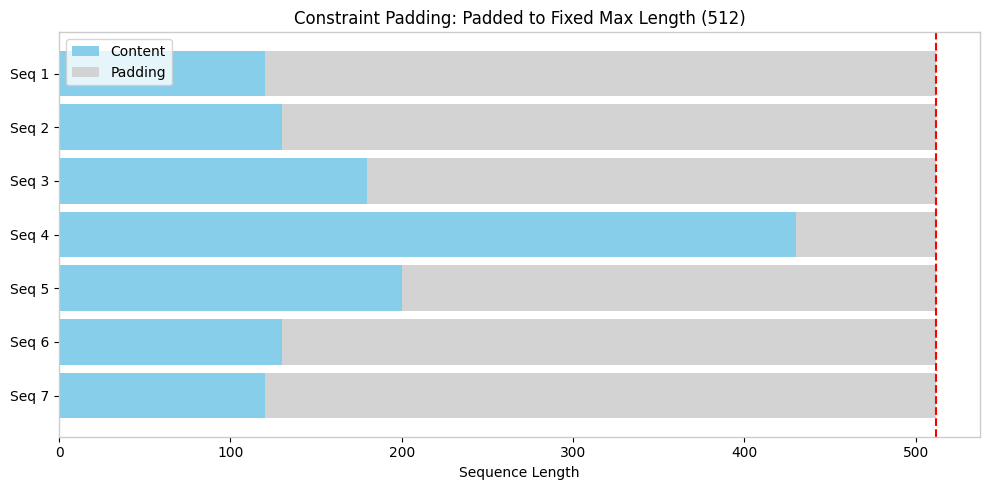

In [10]:
import matplotlib.pyplot as plt
import numpy as np

content_lengths = [120, 130, 180, 430, 200, 130, 120]
max_len = 512
labels = [f"Seq {i+1}" for i in range(len(content_lengths))]

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(content_lengths))

# Content bars
ax.barh(y, content_lengths, color="#87ceeb", label="Content", height=0.85)

# Padding bars (only where content < max_len)
padding = [max(0, max_len - c) for c in content_lengths]
ax.barh(y, padding, left=[min(c, max_len) for c in content_lengths], color="#d3d3d3", label="Padding", height=0.85)

# Red dashed line at the fixed max length
ax.axvline(x=max_len, color="red", linestyle="--", linewidth=1.5)

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Sequence Length")
ax.set_title(f"Constraint Padding: Padded to Fixed Max Length ({max_len})")
ax.legend(loc="upper left")
ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#cccccc")
    spine.set_linewidth(1)

plt.tight_layout()
plt.savefig("constraint_padding.png", dpi=300, bbox_inches="tight")

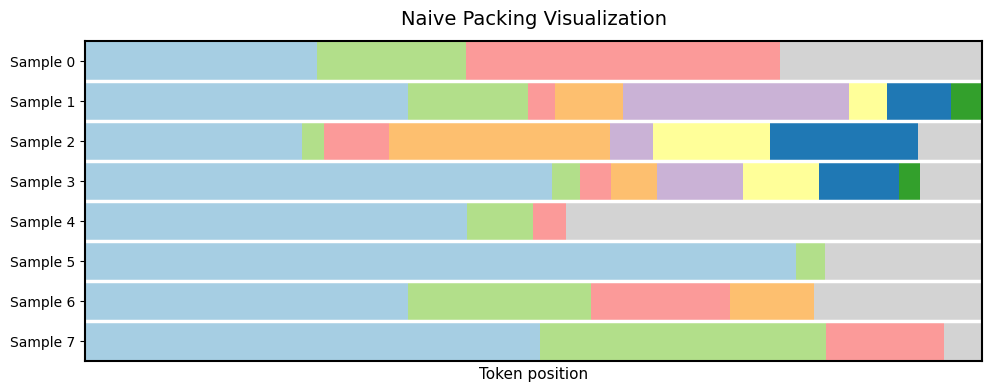

In [1]:
import matplotlib.colors as mcolors

# Example batch from before
max_length = 2048
batch = [
    [528, 342, 715],
    [736, 274, 62, 155, 516, 86, 145, 73],
    [495, 51, 148, 503, 99, 267, 337],
    [1065, 63, 71, 106, 195, 175, 181, 48],
    [872, 150, 75],
    [1622, 66],
    [736, 418, 317, 192],
    [1038, 652, 268],
]

pastel_colors = [
    "#a6cee3",  # light blue
    "#b2df8a",  # light green
    "#fb9a99",  # soft red
    "#fdbf6f",  # light orange
    "#cab2d6",  # lavender
    "#ffff99",  # pale yellow
    "#1f78b4",  # deeper sky blue
    "#33a02c",  # medium green
    "#fbb4ae",  # rose pink
    "#b3cde3",  # powder blue
    "#ccebc5",  # mint
    "#decbe4",  # lilac
    "#fed9a6",  # peach
    "#ffffcc",  # cream
]

# Build visualization array
vis = np.zeros((len(batch), max_length))
for i, sample in enumerate(batch):
    pos = 0
    for j, seg_len in enumerate(sample):
        vis[i, pos:pos+seg_len] = j + 1
        pos += seg_len

# Add gray padding color
colors = ["#d3d3d3"] + pastel_colors
cmap = mcolors.ListedColormap(colors[:len(np.unique(vis))])

# Plot with black border and spacing between rows
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(vis, aspect="auto", cmap=cmap, interpolation="nearest")

# Add black border around the entire plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

# Add white space between rows by shrinking y-limits slightly
ax.set_ylim(len(batch) - 0.5, -0.5)
ax.set_yticks(np.arange(len(batch)))
ax.set_yticklabels([f"Sample {i}" for i in range(len(batch))])
ax.set_xticks([])
ax.set_xlabel("Token position", fontsize=11)
ax.set_title("Naive Packing Visualization", fontsize=14, pad=12)

# Add spacing between rows by overlaying white horizontal lines
for y in np.arange(0.5, len(batch)-0.5, 1):
    ax.axhline(y, color="white", linewidth=2.5)

plt.tight_layout(pad=1.0)
plt.savefig("naive_packing.png", dpi=300, bbox_inches="tight")

In [32]:
from datasets import load_dataset
from transformers import AutoTokenizer

dataset = load_dataset("HuggingFaceM4/FineVisionMax", split="train", streaming=True)
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")

def tokenize_sample(sample):
    messages_list = []
    for data_dict in sample['texts']:
        messages_list.append({'role': 'user', 'content': data_dict['user']})
        messages_list.append({'role': 'assistant', 'content': data_dict['assistant']})
    tokens = tokenizer.apply_chat_template(messages_list, tokenize=True)
    return tokens['input_ids']

pool_tokens = []
pool_size = 50
for sample in dataset:
    toks = tokenize_sample(sample)
    if len(toks) <= max_length:
        pool_tokens.append(toks)
        if len(pool_tokens) >= pool_size:
            break

pool_tokens.sort(key=len, reverse=True) # Sort by length descending

batch_tokens = []
for toks in pool_tokens:
    placed = False
    # Try to place in an existing row
    for row_idx, row in enumerate(batch_tokens):
        curr_len = sum(len(seg) for seg in row)
        if curr_len + len(toks) <= max_length:
            batch_tokens[row_idx].append(toks)
            placed = True
            break
    if placed:
        continue
    # Could not place in any existing row, start a new row if possible
    batch_tokens.append([toks])

Resolving data files:   0%|          | 0/10000 [00:00<?, ?it/s]

In [30]:
from typing import List

def to_vis_matrix(batch_lengths: List[List[int]], max_length: int):
    import numpy as np
    vis = np.zeros((len(batch_lengths), max_length), dtype=int)
    for i, row in enumerate(batch_lengths):
        pos = 0
        for j, seg_len in enumerate(row):
            vis[i, pos:pos+seg_len] = j + 1
            pos += seg_len
    return vis

batch_lengths = [[len(x) for x in y] for y in batch_tokens]
vis = to_vis_matrix(batch_lengths, max_length)

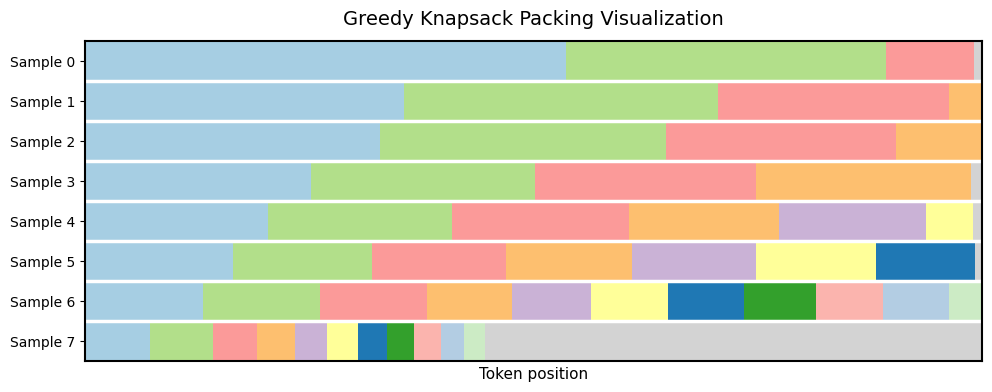

In [31]:
cmap = mcolors.ListedColormap(colors[:len(np.unique(vis))])

# Plot with black border and spacing between rows
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(vis, aspect="auto", cmap=cmap, interpolation="nearest")

# Add black border around the entire plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

# Add white space between rows by shrinking y-limits slightly
ax.set_ylim(len(batch) - 0.5, -0.5)
ax.set_yticks(np.arange(len(batch)))
ax.set_yticklabels([f"Sample {i}" for i in range(len(batch))])
ax.set_xticks([])
ax.set_xlabel("Token position", fontsize=11)
ax.set_title("Greedy Knapsack Packing Visualization", fontsize=14, pad=12)

# Add spacing between rows by overlaying white horizontal lines
for y in np.arange(0.5, len(batch)-0.5, 1):
    ax.axhline(y, color="white", linewidth=2.5)

plt.tight_layout(pad=1.0)
plt.savefig("knapsack_packing.png", dpi=300, bbox_inches="tight")